In [1]:
!pip install -q tensorflow pandas numpy scikit-learn matplotlib joblib

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

In [3]:
np.random.seed(42)
tf.random.set_seed(42)

In [4]:
df = pd.read_csv(
    "financial_health_dataset_bigdata.csv",
    sep=";"
)

print(df.head())

print("\nJumlah data:", len(df))
print("Jumlah kolom:", len(df.columns))

  transaction_id  user_id transaction_datetime    amount category  \
0      TXN000150  USR0001     20/03/2024 01:39  18431360     hobi   
1      TXN002674  USR0001     01/08/2024 22:45   6377100  hiburan   
2      TXN002292  USR0001     04/08/2024 12:11   5125420  hiburan   
3      TXN000001  USR0001     05/09/2024 22:53   5081860  hiburan   
4      TXN002969  USR0001     08/09/2024 13:51   1059920      F&B   

   is_budgeted  is_late_night  is_weekend  is_unbudgeted  is_risky_category  \
0        False              1           0              1                  0   
1        False              1           0              1                  1   
2        False              0           1              1                  1   
3        False              1           0              1                  1   
4        False              0           1              1                  1   

   ...  wants_spending  saving_rate_score  wants_ratio_score  dti_score  \
0  ...        22622050             

In [5]:
DROP_COLUMNS = [
    'saving_rate_score',
    'wants_ratio_score',
    'dti_score',
    'investment_rate_score',
    'health_score_original',
    'impulsive_score',
    'impulsive_flag',
    'budget_adherence',
    'impulsive_component'
]

df = df.drop(
    columns=DROP_COLUMNS,
    errors='ignore'
)

print(df.columns.tolist())

['transaction_id', 'user_id', 'transaction_datetime', 'amount', 'category', 'is_budgeted', 'is_late_night', 'is_weekend', 'is_unbudgeted', 'is_risky_category', 'is_binge_spending', 'hourly_txn_count', 'income_monthly', 'total_debt_payment', 'dti_ratio', 'dti_segment', 'investment_amount', 'total_expense', 'wants_spending', 'health_score', 'health_label']


In [6]:
df['transaction_datetime'] = pd.to_datetime(
    df['transaction_datetime'],
    dayfirst=True,
    errors='coerce'
)

df['month'] = (
    df['transaction_datetime']
    .dt.to_period('M')
    .astype(str)
)

In [7]:
df['is_budgeted'] = df['is_budgeted'].map(
    {
        True: 1,
        False: 0,
        'TRUE': 1,
        'FALSE': 0,
        'True': 1,
        'False': 0
    }
).fillna(0).astype(int)

In [8]:
if 'is_unbudgeted' in df.columns:

    inconsistent = (
        (df['is_budgeted'] == 1)
        &
        (df['is_unbudgeted'] == 1)
    ).sum()

    if inconsistent > 0:
        print(
            f"{inconsistent} inconsistent rows fixed"
        )

        df['is_unbudgeted'] = (
            1 - df['is_budgeted']
        )

In [9]:
print(
    "dti_ratio max:",
    df['dti_ratio'].max()
)

if df['dti_ratio'].max() > 10:

    print("Fixing dti_ratio...")

    df['dti_ratio'] = (
        df['total_debt_payment']
        /
        df['income_monthly']
        .replace(0, np.nan)
    ).clip(0, 1)

    df['dti_ratio'] = (
        df['dti_ratio']
        .fillna(0)
    )

dti_ratio max: 6988
Fixing dti_ratio...


In [10]:
print(
    "\nMissing values:"
)

print(
    df.isnull().sum()[
        df.isnull().sum() > 0
    ]
)


Missing values:
Series([], dtype: int64)


In [11]:
print(
    "\nDistribusi health_label:"
)

print(
    df['health_label']
    .value_counts()
)

print(
    "\nHealth score range:",
    df['health_score'].min(),
    "-",
    df['health_score'].max()
)


Distribusi health_label:
health_label
Sehat        11240
Cukup         7220
Excellent     3370
Kritis        2645
Waspada        525
Name: count, dtype: int64

Health score range: 0.0 - 100.0


In [12]:
monthly = df.groupby(
    ['user_id', 'month']
).agg({

    'is_late_night': 'mean',
    'is_weekend': 'mean',
    'is_unbudgeted': 'mean',
    'is_risky_category': 'mean',
    'is_binge_spending': 'mean',

    'hourly_txn_count': 'mean',

    'amount': 'count',

    'income_monthly': 'mean',
    'total_expense': 'mean',
    'wants_spending': 'sum',
    'investment_amount': 'mean',

    'dti_ratio': 'mean',
    'dti_segment': 'first',

    'health_score': 'mean'

}).reset_index()

In [13]:
monthly = monthly.rename(
    columns={
        'is_late_night':
            'pct_late_night',

        'is_weekend':
            'pct_weekend',

        'is_unbudgeted':
            'pct_unbudgeted',

        'is_risky_category':
            'pct_risky_category',

        'is_binge_spending':
            'pct_binge_spending',

        'hourly_txn_count':
            'avg_hourly_txn_count',

        'amount':
            'transaction_count'
    }
)

In [14]:
monthly['saving_rate_raw'] = (
    (
        monthly['income_monthly']
        -
        monthly['total_expense']
    )
    /
    monthly['income_monthly']
    .replace(0, np.nan)
).clip(0, 1).fillna(0)

monthly['wants_ratio_raw'] = (
    monthly['wants_spending']
    /
    monthly['income_monthly']
    .replace(0, np.nan)
).clip(0, 1).fillna(0)

monthly['investment_rate_raw'] = (
    monthly['investment_amount']
    /
    monthly['income_monthly']
    .replace(0, np.nan)
).clip(0, 1).fillna(0)

monthly['segment_enc'] = (
    monthly['dti_segment'] == 'B'
).astype(int)

In [15]:
FEATURES_A = [
    'pct_late_night',
    'pct_weekend',
    'pct_unbudgeted',
    'pct_risky_category',
    'pct_binge_spending',
    'avg_hourly_txn_count',
    'transaction_count'
]

In [16]:
FEATURES_B = [
    'saving_rate_raw',
    'wants_ratio_raw',
    'investment_rate_raw',
    'dti_ratio',
    'segment_enc'
]

In [17]:
SAFE_FEATURES = [
    'pct_late_night',
    'pct_weekend',
    'pct_unbudgeted',
    'pct_risky_category',
    'pct_binge_spending',
    'avg_hourly_txn_count',
    'transaction_count',
    'saving_rate_raw',
    'wants_ratio_raw',
    'investment_rate_raw',
    'dti_ratio',
    'segment_enc'
]

In [18]:
corr = (
    monthly[
        SAFE_FEATURES +
        ['health_score']
    ]
    .corr()['health_score']
)

corr_sorted = (
    corr
    .drop('health_score')
    .abs()
    .sort_values(
        ascending=False
    )
)

print(corr_sorted)

leaky = corr_sorted[
    corr_sorted > 0.99
]

if len(leaky) > 0:
    print(
        "\nLEAKAGE DETECTED:",
        leaky.index.tolist()
    )
else:
    print(
        "\nTidak ada leakage"
    )

saving_rate_raw         0.177047
pct_unbudgeted          0.145143
dti_ratio               0.140224
wants_ratio_raw         0.120118
pct_late_night          0.097759
segment_enc             0.062901
investment_rate_raw     0.044449
transaction_count       0.021416
pct_weekend             0.017946
pct_risky_category      0.011696
avg_hourly_txn_count    0.003870
pct_binge_spending           NaN
Name: health_score, dtype: float64

Tidak ada leakage


In [19]:
X = monthly[
    SAFE_FEATURES
]

y = monthly[
    'health_score'
].astype(np.float32)

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

joblib.dump(
    scaler,
    'scaler.pkl'
)

['scaler.pkl']

In [22]:
@tf.keras.utils.register_keras_serializable()
class FinancialAttentionLayer(
    tf.keras.layers.Layer
):

    def __init__(
        self,
        units=13,
        **kwargs
    ):
        super().__init__(**kwargs)

        self.units = units

        self.score_dense = tf.keras.layers.Dense(
            units,
            activation='tanh'
        )

        self.weight_dense = tf.keras.layers.Dense(
            units,
            activation='softmax'
        )

    def call(
        self,
        inputs
    ):
        scores = self.score_dense(
            inputs
        )

        weights = self.weight_dense(
            scores
        )

        return inputs * weights

    def get_config(
        self
    ):
        config = super().get_config()

        config.update({
            'units': self.units
        })

        return config

In [23]:
@tf.keras.utils.register_keras_serializable()
def custom_health_loss(
    y_true,
    y_pred
):

    y_true = tf.cast(
        y_true,
        tf.float32
    )

    y_pred = tf.cast(
        y_pred,
        tf.float32
    )

    error = tf.abs(
        y_true - y_pred
    )

    penalty = tf.where(
        y_true < 40,
        error * 2.0,
        error
    )

    return tf.reduce_mean(
        penalty
    )

In [24]:
class CustomTrainingMonitor(
    tf.keras.callbacks.Callback
):

    def on_epoch_end(
        self,
        epoch,
        logs=None
    ):
        print(
            f"Epoch {epoch+1} | "
            f"Loss: {logs['loss']:.4f} | "
            f"Val Loss: {logs['val_loss']:.4f} | "
            f"MAE: {logs['mae']:.4f}"
        )

In [25]:
inputs = tf.keras.Input(
    shape=(X_train.shape[1],)
)

x = FinancialAttentionLayer(
    X_train.shape[1]
)(inputs)

x = tf.keras.layers.Dense(
    64,
    activation='relu'
)(x)

x = tf.keras.layers.Dropout(
    0.3
)(x)

x = tf.keras.layers.Dense(
    32,
    activation='relu'
)(x)

outputs = tf.keras.layers.Dense(
    1,
    activation='linear'
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ financial_attention_layer       │ (None, 12)             │           312 │
│ (FinancialAttentionLayer)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,257 (12.72 KB)

 Trainable params: 3,257 (12.72 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss=custom_health_loss,
    metrics=['mae']
)

In [30]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[
        CustomTrainingMonitor(),

        tf.keras.callbacks.EarlyStopping(
            patience=10,
            restore_best_weights=True
        )
    ]
)

Epoch 1/50
65/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.6301 - mae: 14.2396Epoch 1 | Loss: 20.2768 | Val Loss: 20.5381 | MAE: 14.4415
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 20.2768 - mae: 14.4415 - val_loss: 20.5381 - val_mae: 14.5231
Epoch 2/50
77/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.6435 - mae: 14.1258Epoch 2 | Loss: 20.0611 | Val Loss: 20.5763 | MAE: 14.2481
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 20.0611 - mae: 14.2481 - val_loss: 20.5763 - val_mae: 14.5959
Epoch 3/50
76/82 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 19.7140 - mae: 14.2028Epoch 3 | Loss: 20.0163 | Val Loss: 20.5530 | MAE: 14.2092
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 20.0163 - mae: 14.2092 - val_loss: 20.5530 - val_mae: 14.5337
Epoch 4/50
64/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 19.8852 - mae: 14.4107Epoch 4 | Loss: 20.0780 | Val Loss: 20.5934 | MAE: 14.2788
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20.0780 - mae: 14.2788 - val_loss: 20.5934 - val_mae: 14.6939
Epoch 5/

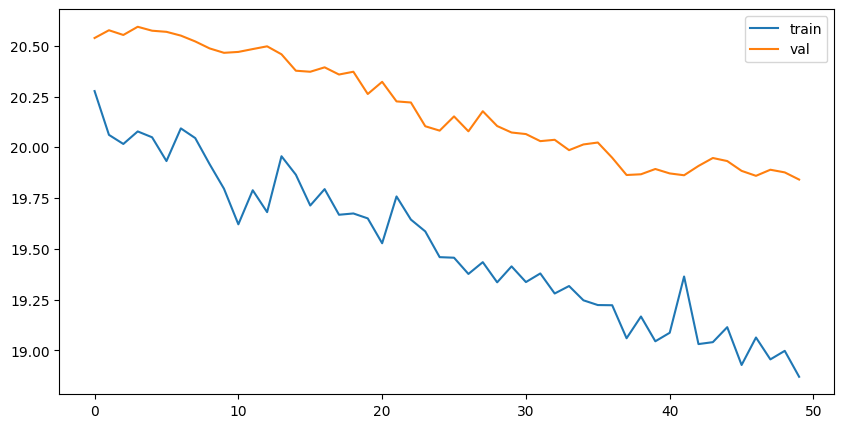

In [31]:
plt.figure(
    figsize=(10,5)
)

plt.plot(
    history.history['loss'],
    label='train'
)

plt.plot(
    history.history['val_loss'],
    label='val'
)

plt.legend()
plt.show()

In [32]:
predictions = model.predict(
    X_test
)

mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

print("MAE :", mae)
print("RMSE:", rmse)

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
MAE : 14.299027442932129
RMSE: 21.404636829042513


In [33]:
model.save(
    "financial_health_model.keras"
)

joblib.dump(
    SAFE_FEATURES,
    "feature_columns.pkl"
)

print(
    "Model saved!"
)

Model saved!


In [34]:
loaded_model = tf.keras.models.load_model(
    "financial_health_model.keras",
    custom_objects={
        "FinancialAttentionLayer":
            FinancialAttentionLayer,
        "custom_health_loss":
            custom_health_loss
    }
)

sample = X.iloc[:1]

sample_scaled = scaler.transform(
    sample
)

prediction = loaded_model.predict(
    sample_scaled
)

score = float(
    prediction[0][0]
)

def health_label(score):

    if score < 20:
        return "KRITIS"

    elif score < 40:
        return "WASPADA"

    elif score < 60:
        return "CUKUP"

    elif score < 80:
        return "SEHAT"

    else:
        return "EXCELLENT"

label = health_label(score)

print(
    "Predicted health score:",
    round(score, 2)
)

print(
    "Health label:",
    label
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'financial_attention_layer', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Predicted health score: 65.77
Health label: SEHAT


In [35]:
train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
).shuffle(1000).batch(32)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
).batch(32)

optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.001
)

train_loss_metric = tf.keras.metrics.Mean()
val_loss_metric = tf.keras.metrics.Mean()


@tf.function
def train_step(
    x_batch,
    y_batch
):


    with tf.GradientTape() as tape:

        preds = model(
            x_batch,
            training=True
        )
        loss = custom_health_loss(
            y_batch,
            preds
        )

    grads = tape.gradient(
        loss,
        model.trainable_variables
    )

    optimizer.apply_gradients(
        zip(
            grads,
            model.trainable_variables
        )
    )

    train_loss_metric.update_state(
        loss
    )


@tf.function
def val_step(
    x_batch,
    y_batch
):

    preds = model(
        x_batch,
        training=False
    )

    loss = custom_health_loss(
        y_batch,
        preds
    )

    val_loss_metric.update_state(
        loss
    )


EPOCHS = 10

for epoch in range(EPOCHS):

    train_loss_metric.reset_state()
    val_loss_metric.reset_state()

    for x_batch, y_batch in train_ds:
        train_step(
            x_batch,
            y_batch
        )

    for x_batch, y_batch in val_ds:
        val_step(
            x_batch,
            y_batch
        )

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss_metric.result():.4f} | "
        f"Val Loss: {val_loss_metric.result():.4f}"
    )

Epoch 1 | Train Loss: 26.2130 | Val Loss: 26.0855
Epoch 2 | Train Loss: 25.2581 | Val Loss: 25.6205
Epoch 3 | Train Loss: 24.9805 | Val Loss: 25.4615
Epoch 4 | Train Loss: 24.9190 | Val Loss: 25.4077
Epoch 5 | Train Loss: 24.8732 | Val Loss: 25.3777
Epoch 6 | Train Loss: 24.8737 | Val Loss: 25.3391
Epoch 7 | Train Loss: 24.8267 | Val Loss: 25.3371
Epoch 8 | Train Loss: 24.8097 | Val Loss: 25.3130
Epoch 9 | Train Loss: 24.8110 | Val Loss: 25.3098
Epoch 10 | Train Loss: 24.7640 | Val Loss: 25.2931
